# Paper Figure Generation

This notebook is only for generating figures for the manuscript draft in `docs/tex_draft/`.

The first pass here builds two Figure 1 panels:

- a WT calibration panel for `wt_divMean0Stdev26`, `sim61`, `VCV=1`
- representative WT endpoint outputs selected from the 10th, 50th, and 90th percentiles of lineage volume

All outputs are saved to `docs/tex_draft/figures/`.


In [1]:
from __future__ import annotations

import json
from functools import lru_cache
from pathlib import Path
import sys

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Polygon


def find_repo_root(start: Path | None = None) -> Path:
    path = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [path, *path.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "npa").exists():
            return candidate
    raise RuntimeError("Could not locate repo root from the current working directory.")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

FIG_DIR = REPO_ROOT / "docs" / "tex_draft" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

_style_dir = str(REPO_ROOT / "docs" / "tex_draft")
if _style_dir not in sys.path:
    sys.path.insert(0, _style_dir)
from _style import RCPARAMS as _RCPARAMS, FONT_SIZE_TITLE, FONT_SIZE_LABEL, FONT_SIZE_SMALL, EXP_FILL_COLOR, EXP_MEDIAN_COLOR
mpl.rcParams.update(_RCPARAMS)

print(f"Repo root: {REPO_ROOT}")
print(f"Figure output dir: {FIG_DIR}")


Repo root: /Users/skjannetty/bagherilab/neurogen-plane-rotation-analysis
Figure output dir: /Users/skjannetty/bagherilab/neurogen-plane-rotation-analysis/docs/tex_draft/figures


In [2]:
from npa.sim_preprocessing import _load_json, build_label_map, build_raw_tensor
from npa.sim_viz import NB_COLOR, POP2_COLOR, POP3_COLOR, add_scale_bar, load_raw_snapshot_full, render_raw

WT_CONDITION = "wt_divMean0Stdev26"
WT_SIM_ID = "vcv1_noreg"
WT_VCV = 1
REPRESENTATIVE_PERCENTILES = (0.10, 0.50, 0.90)
EXPERIMENTAL_PERCENTILE_OVERRIDES = {0.90: 126}
DS_UM_PER_VOX = 0.3
AREA_SCALE = DS_UM_PER_VOX ** 2
EXPERIMENTAL_NONNB_COLOR = "#259eae"

SIM_METRICS_CSV = REPO_ROOT / "data" / "sim" / "processed_sweep" / "sim_metrics_last.csv"
SIM_RUN_INDEX_CSV = REPO_ROOT / "data" / "sim" / "processed_sweep" / "sim_run_index.csv"
EXP_SUMMARY_CSV = REPO_ROOT / "data" / "exp" / "processed" / "exp_summary.csv"
EXP_INDEX_CSV = REPO_ROOT / "data" / "exp" / "processed" / "lineage_index.csv"
EXP_WT_ANALYSIS_NPZ = REPO_ROOT / "data" / "exp" / "processed" / "analysis" / "wt.npz"

sim_df = pd.read_csv(SIM_METRICS_CSV)
run_index_df = pd.read_csv(SIM_RUN_INDEX_CSV)
exp_df = pd.read_csv(EXP_SUMMARY_CSV)
exp_index_df = pd.read_csv(EXP_INDEX_CSV)

wt_runs = sim_df[
    (sim_df["condition"] == WT_CONDITION)
    & (sim_df["sim_id"] == WT_SIM_ID)
    & (sim_df["critical_volume_mode"] == WT_VCV)
].copy().sort_values("run_id")

if wt_runs.empty:
    raise RuntimeError("No WT runs found for the requested condition.")

exp_wt_lineages = exp_index_df.loc[exp_index_df["genotype"] == "wt"].copy().sort_values("analysis_row").reset_index(drop=True)
with np.load(EXP_WT_ANALYSIS_NPZ) as exp_analysis:
    exp_wt_lineages["occupied_vox"] = exp_analysis["geo"].sum(axis=(1, 2, 3))
    exp_wt_lineages["lin_area_vox"] = exp_wt_lineages["occupied_vox"]
    exp_wt_lineages["dpn_area_vox"] = exp_analysis["counts"][:, 2]
    exp_wt_lineages["avg_dpn_area_vox"] = exp_wt_lineages["dpn_area_vox"] / exp_wt_lineages["n_dpn"].clip(lower=1)

METRIC_SPECS = [
    {"key": "lin_area_vox",     "title": "Lineage area",  "unit": "µm²",       "is_area": True},
    {"key": "dpn_area_vox",     "title": "Total NB area", "unit": "µm²",       "is_area": True},
    {"key": "avg_dpn_area_vox", "title": "Mean NB area",  "unit": "µm²/cell",  "is_area": True},
    {"key": "n_pros",           "title": "Pros count",    "unit": "cells",      "is_area": False},
    {"key": "n_dpn",            "title": "NB count",      "unit": "cells",      "is_area": False},
]

wt_runs[["run_id", "lin_area_vox", "n_pros", "n_dpn", "dpn_area_vox", "avg_dpn_area_vox"]].head()


,run_id,lin_area_vox,n_pros,n_dpn,dpn_area_vox,avg_dpn_area_vox
950,1,5681,47,1,729,729.0
951,2,5936,46,1,739,739.0
952,3,5782,48,1,647,647.0
953,4,5796,46,1,713,713.0
954,5,5949,45,1,709,709.0


In [3]:
def ordinal(n: int) -> str:
    if 10 <= n % 100 <= 20:
        suffix = "th"
    else:
        suffix = {1: "st", 2: "nd", 3: "rd"}.get(n % 10, "th")
    return f"{n}{suffix}"


def pick_percentile_runs(df: pd.DataFrame, metric: str, percentiles: tuple[float, ...]) -> pd.DataFrame:
    chosen_rows = []
    if "run_id" in df.columns:
        id_col = "run_id"
    elif "lineage_id" in df.columns:
        id_col = "lineage_id"
    else:
        raise KeyError("pick_percentile_runs requires either 'run_id' or 'lineage_id'.")

    used_ids: set[int] = set()

    for pct in percentiles:
        target = df[metric].quantile(pct)
        candidates = df.copy()
        candidates["abs_delta"] = (candidates[metric] - target).abs()
        candidates = candidates.sort_values(["abs_delta", metric, id_col], kind="stable")

        for _, row in candidates.iterrows():
            entity_id = int(row[id_col])
            if entity_id in used_ids:
                continue
            used_ids.add(entity_id)
            payload = row.drop(labels=["abs_delta"]).to_dict()
            payload["percentile"] = pct
            payload["target_value"] = float(target)
            chosen_rows.append(payload)
            break

    return pd.DataFrame(chosen_rows).sort_values("percentile").reset_index(drop=True)


def crop_to_content(arr: np.ndarray, pad: int = 6) -> np.ndarray:
    occ = arr.any(axis=-1) if arr.ndim == 3 else arr > 0
    ys, xs = np.where(occ)
    if len(xs) == 0 or len(ys) == 0:
        return arr

    y0 = max(int(ys.min()) - pad, 0)
    y1 = min(int(ys.max()) + pad + 1, arr.shape[0])
    x0 = max(int(xs.min()) - pad, 0)
    x1 = min(int(xs.max()) + pad + 1, arr.shape[1])

    if arr.ndim == 3:
        return arr[y0:y1, x0:x1, :]
    return arr[y0:y1, x0:x1]


def load_run_snapshot(run_id: int) -> tuple[np.ndarray, np.ndarray, pd.Series]:
    row = run_index_df[
        (run_index_df["condition"] == WT_CONDITION)
        & (run_index_df["sim_id"] == WT_SIM_ID)
        & (run_index_df["run_id"].astype(int) == run_id)
    ].iloc[0]

    cells_path = REPO_ROOT / row["cells_path"]
    locs_path = REPO_ROOT / row["locs_path"]
    geo_raw, label_map = load_raw_snapshot_full(cells_path, locs_path)
    return geo_raw, label_map, row


def load_exp_mesh(mesh_path: str | Path) -> dict[str, np.ndarray]:
    mesh_path = Path(mesh_path)
    if not mesh_path.is_absolute():
        mesh_path = REPO_ROOT / mesh_path
    with np.load(mesh_path) as data:
        return {key: data[key] for key in data.files}


def render_exp_centroid_lineage(ax: plt.Axes, mesh: dict[str, np.ndarray], hull_face_color: str = "#efefef", hull_edge_color: str = "#d8d8d8") -> None:
    poly = np.asarray(mesh["lin_poly_2d_px"], dtype=float)
    dpn = np.asarray(mesh["dpn_centroids_2d_px"], dtype=float).reshape(-1, 2)
    pros = np.asarray(mesh["pros_centroids_2d_px"], dtype=float).reshape(-1, 2)

    ax.add_patch(
        Polygon(
            poly,
            closed=True,
            facecolor=hull_face_color,
            edgecolor=hull_edge_color,
            linewidth=0.9,
            joinstyle="round",
            zorder=1,
        )
    )

    if len(pros) > 0:
        ax.scatter(
            pros[:, 0],
            pros[:, 1],
            s=52,
            c=EXPERIMENTAL_NONNB_COLOR,
            edgecolors="none",
            zorder=3,
        )
    if len(dpn) > 0:
        ax.scatter(
            dpn[:, 0],
            dpn[:, 1],
            s=700,
            c=NB_COLOR,
            edgecolors="white",
            linewidths=0.4,
            zorder=4,
        )

    x0, y0 = poly.min(axis=0)
    x1, y1 = poly.max(axis=0)
    pad = 8
    cx = 0.5 * (x0 + x1)
    cy = 0.5 * (y0 + y1)
    span = max((x1 - x0), (y1 - y0)) + 2 * pad
    half = 0.5 * span
    ax.set_xlim(max(cx - half, 0), min(cx + half, 200))
    ax.set_ylim(min(cy + half, 200), max(cy - half, 0))
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)


def metric_display_values(values: np.ndarray, spec: dict, /) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    if spec["is_area"]:
        return values * AREA_SCALE
    return values


def apply_experimental_percentile_overrides(selected: pd.DataFrame, source_df: pd.DataFrame, overrides: dict[float, int]) -> pd.DataFrame:
    if not overrides:
        return selected

    out_rows: list[dict] = []
    for _, selected_row in selected.iterrows():
        pct = float(selected_row["percentile"])
        if pct not in overrides:
            out_rows.append(selected_row.to_dict())
            continue

        lineage_id = overrides[pct]
        replacement = source_df.loc[source_df["lineage_id"] == lineage_id]
        if replacement.empty:
            raise KeyError(f"Experimental override lineage_id {lineage_id} not found.")

        row = replacement.iloc[0].to_dict()
        row["percentile"] = pct
        row["target_value"] = float(source_df["occupied_vox"].quantile(pct))
        out_rows.append(row)

    return pd.DataFrame(out_rows).sort_values("percentile").reset_index(drop=True)


def metric_display_scalar(value: float, spec: dict, /) -> float:
    if spec["is_area"]:
        return float(value) * AREA_SCALE
    return float(value)


def style_calibration_axis(ax: plt.Axes) -> None:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.grid(axis="y", color="#d0d0d0", linewidth=0.6, alpha=0.5)
    ax.tick_params(axis="x", length=0)


def make_wt_calibration_figure() -> tuple[plt.Figure, list[plt.Axes]]:
    fig, axes = plt.subplots(1, len(METRIC_SPECS), figsize=(11.0, 3.8))

    for ax, spec in zip(axes, METRIC_SPECS):
        exp_values = metric_display_values(exp_wt_lineages[spec["key"]].astype(float).to_numpy(), spec)
        sim_values = metric_display_values(wt_runs[spec["key"]].astype(float).to_numpy(), spec)

        bp = ax.boxplot(
            [exp_values, sim_values],
            positions=[1.0, 2.0],
            widths=0.48,
            patch_artist=True,
            showfliers=False,
            medianprops={"color": "black", "linewidth": 1.3},
            boxprops={"facecolor": "white", "edgecolor": "black", "linewidth": 1.0},
            whiskerprops={"color": "black", "linewidth": 0.9},
            capprops={"color": "black", "linewidth": 0.9},
            manage_ticks=False,
            zorder=3,
        )
        bp["boxes"][0].set_facecolor(EXP_FILL_COLOR)
        bp["boxes"][1].set_facecolor("white")
        bp["medians"][0].set(color=EXP_MEDIAN_COLOR, linewidth=1.8, linestyle="--")

        data_lo = min(exp_values.min(), sim_values.min())
        data_hi = max(exp_values.max(), sim_values.max())
        if np.isclose(data_lo, data_hi):
            pad = 0.3 * max(1.0, abs(data_hi))
        else:
            pad = 0.18 * (data_hi - data_lo)

        ax.set_ylim(data_lo - pad, data_hi + pad)
        ax.set_xlim(0.45, 2.55)
        ax.set_xticks([1.0, 2.0], ["Exp", "Sim"])
        ax.set_title(spec["title"])
        ax.set_ylabel(spec["unit"])
        style_calibration_axis(ax)

    fig.tight_layout()
    return fig, list(axes)


def rotate_mesh_2d(mesh: dict, angle_deg: float) -> dict:
    theta = np.radians(angle_deg)
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])
    poly = np.array(mesh["lin_poly_2d_px"], dtype=float).reshape(-1, 2)
    center = poly.mean(axis=0)
    result = dict(mesh)
    for key in ("lin_poly_2d_px", "dpn_centroids_2d_px", "pros_centroids_2d_px"):
        if key not in mesh or len(mesh[key]) == 0:
            continue
        pts = np.array(mesh[key], dtype=float).reshape(-1, 2)
        result[key] = (R @ (pts - center).T).T + center
    return result


# positive = CCW, negative = CW
EXP_LINEAGE_ROTATIONS = {135: -90, 169: 90, 126: 90}


def make_wt_examples_figure(sim_selected_runs: pd.DataFrame, exp_selected_lineages: pd.DataFrame) -> tuple[plt.Figure, np.ndarray]:
    fig, axes = plt.subplots(2, len(sim_selected_runs), figsize=(11.0, 7.8))

    for ax, (_, row) in zip(axes[0], sim_selected_runs.iterrows()):
        run_id = int(row["run_id"])
        geo_raw, label_map, _ = load_run_snapshot(run_id)
        geo_crop = crop_to_content(geo_raw, pad=6)
        label_crop = crop_to_content(label_map, pad=6)

        render_raw(geo_crop, ax=ax, label_map=label_crop, title="")
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

        pct_label = ordinal(int(round(float(row['percentile']) * 100)))
        ax.set_title(f"{pct_label} percentile\nlineage area", pad=6)
        ax.set_xlabel(
            f"run {run_id:04d}\nlineage area = {row['lin_area_vox'] * AREA_SCALE:.1f} µm²",
            fontsize=FONT_SIZE_LABEL,
            labelpad=4,
        )

    for ax, (_, row) in zip(axes[1], exp_selected_lineages.iterrows()):
        mesh = load_exp_mesh(row['mesh_path'])
        lineage_id = int(row["lineage_id"])
        if lineage_id in EXP_LINEAGE_ROTATIONS:
            mesh = rotate_mesh_2d(mesh, EXP_LINEAGE_ROTATIONS[lineage_id])
        render_exp_centroid_lineage(ax, mesh)
        ax.set_xlabel(
            f"lineage {int(row['lineage_id'])}\nlineage area = {row['occupied_vox'] * AREA_SCALE:.1f} µm²",
            fontsize=FONT_SIZE_LABEL,
            labelpad=4,
        )

    for ax in axes[0]:
        ax.xaxis.set_label_coords(0.5, -0.058)
    for ax in axes[1]:
        ax.xaxis.set_label_coords(0.5, -0.058)

    fig.text(0.028, 0.72, 'simulation', rotation=90, va='center', ha='center', fontsize=FONT_SIZE_TITLE)
    fig.text(0.028, 0.245, 'experiment', rotation=90, va='center', ha='center', fontsize=FONT_SIZE_TITLE)
    fig.tight_layout()
    fig.subplots_adjust(hspace=0.24)
    return fig, axes


## Representative lineages for the two-row examples panel

- `representative_runs` drives the **simulation** row.
- `representative_exp_lineages` drives the **experimental** row.
- The experimental row is rendered inside `make_wt_examples_figure(...)` via `render_exp_centroid_lineage(...)`.


In [4]:
representative_runs = pick_percentile_runs(wt_runs, metric="lin_area_vox", percentiles=REPRESENTATIVE_PERCENTILES)
representative_runs[["percentile", "run_id", "target_value", "lin_area_vox", "n_pros", "n_dpn", "dpn_area_vox", "avg_dpn_area_vox"]]


,percentile,run_id,target_value,lin_area_vox,n_pros,n_dpn,dpn_area_vox,avg_dpn_area_vox
0,0.1,23,5709.8,5710,48,1,659,659.0
1,0.5,31,5837.0,5835,46,1,741,741.0
2,0.9,40,5999.5,5999,46,1,738,738.0


In [5]:
representative_exp_lineages = pick_percentile_runs(exp_wt_lineages, metric="occupied_vox", percentiles=REPRESENTATIVE_PERCENTILES)
representative_exp_lineages = apply_experimental_percentile_overrides(
    representative_exp_lineages,
    exp_wt_lineages,
    EXPERIMENTAL_PERCENTILE_OVERRIDES,
)
representative_exp_lineages[["percentile", "lineage_id", "target_value", "occupied_vox", "n_pros", "n_dpn", "mesh_path"]]


,percentile,lineage_id,target_value,occupied_vox,n_pros,n_dpn,mesh_path
0,0.1,135,3955.8,3957.0,23,1,data/exp/processed/meshes/wt/lobe7_9.npz
1,0.5,169,5310.5,5307.0,54,1,data/exp/processed/meshes/wt/lobe15_5.npz
2,0.9,126,7570.2,7480.0,58,1,data/exp/processed/meshes/wt/lobe2_12.npz


Saved: /Users/skjannetty/bagherilab/neurogen-plane-rotation-analysis/docs/tex_draft/figures/figure1_wt_calibration_panel.png
Saved: /Users/skjannetty/bagherilab/neurogen-plane-rotation-analysis/docs/tex_draft/figures/figure1_wt_calibration_panel.pdf


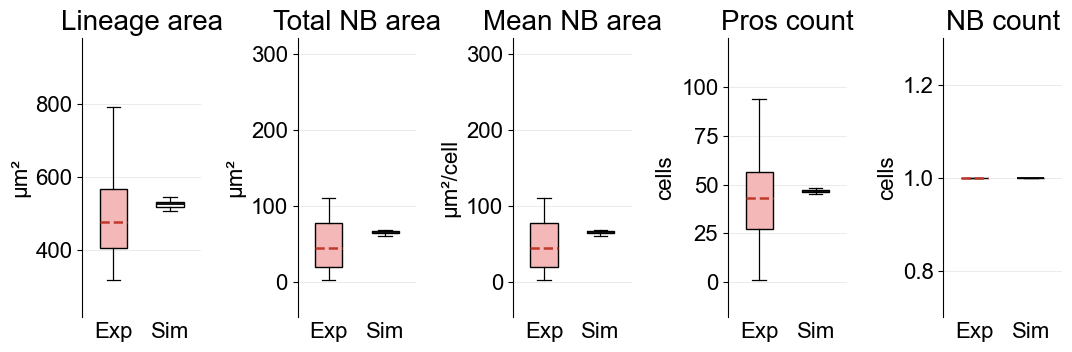

In [6]:
calibration_fig, calibration_axes = make_wt_calibration_figure()
calibration_png = FIG_DIR / "figure1_wt_calibration_panel.png"
calibration_pdf = FIG_DIR / "figure1_wt_calibration_panel.pdf"
calibration_fig.savefig(calibration_png, bbox_inches="tight", facecolor="white")
calibration_fig.savefig(calibration_pdf, bbox_inches="tight", facecolor="white")
print(f"Saved: {calibration_png}")
print(f"Saved: {calibration_pdf}")
plt.show()


Saved: /Users/skjannetty/bagherilab/neurogen-plane-rotation-analysis/docs/tex_draft/figures/figure1_wt_examples_panel.png
Saved: /Users/skjannetty/bagherilab/neurogen-plane-rotation-analysis/docs/tex_draft/figures/figure1_wt_examples_panel.pdf


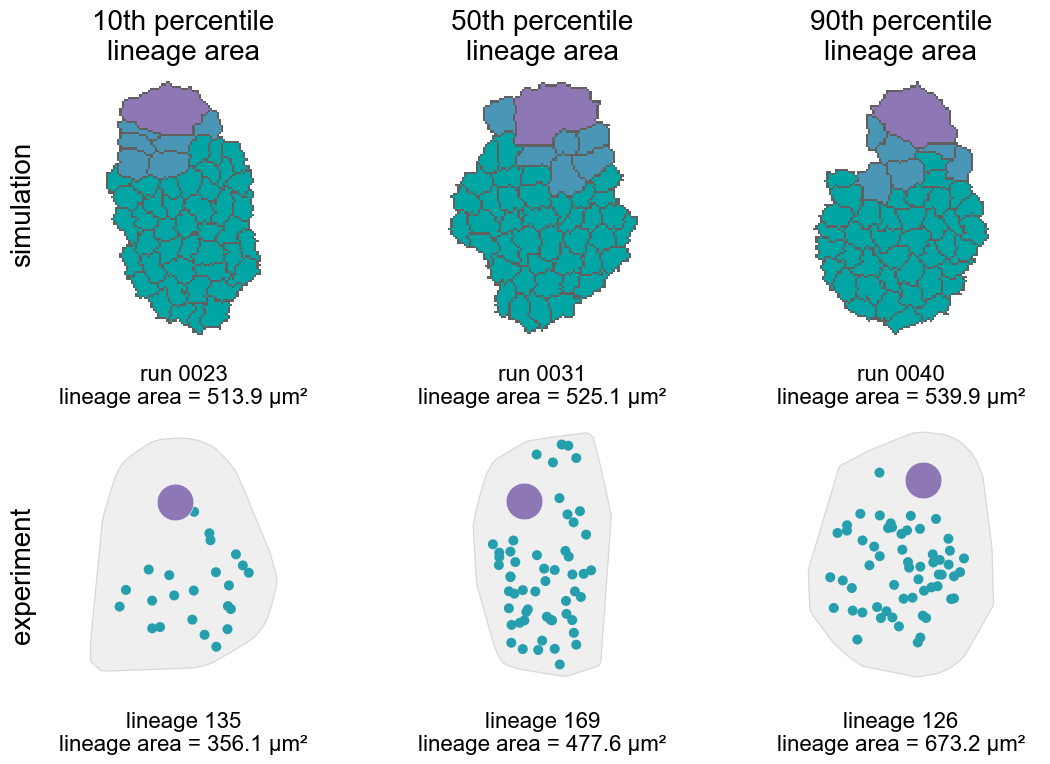

In [7]:
examples_fig, examples_axes = make_wt_examples_figure(representative_runs, representative_exp_lineages)
examples_png = FIG_DIR / "figure1_wt_examples_panel.png"
examples_pdf = FIG_DIR / "figure1_wt_examples_panel.pdf"
examples_fig.savefig(examples_png, bbox_inches="tight", facecolor="white")
examples_fig.savefig(examples_pdf, bbox_inches="tight", facecolor="white")
print(f"Saved: {examples_png}")
print(f"Saved: {examples_pdf}")
plt.show()


## Figure 2 panels

These panels use the calibrated WT regime only (`sim61`, `VCV=1`) and summarize the geometry-decoupling sweeps.


Saved: /Users/skjannetty/bagherilab/neurogen-plane-rotation-analysis/docs/tex_draft/figures/figure2_wt_geometry_examples_panel.png
Saved: /Users/skjannetty/bagherilab/neurogen-plane-rotation-analysis/docs/tex_draft/figures/figure2_wt_geometry_examples_panel.pdf


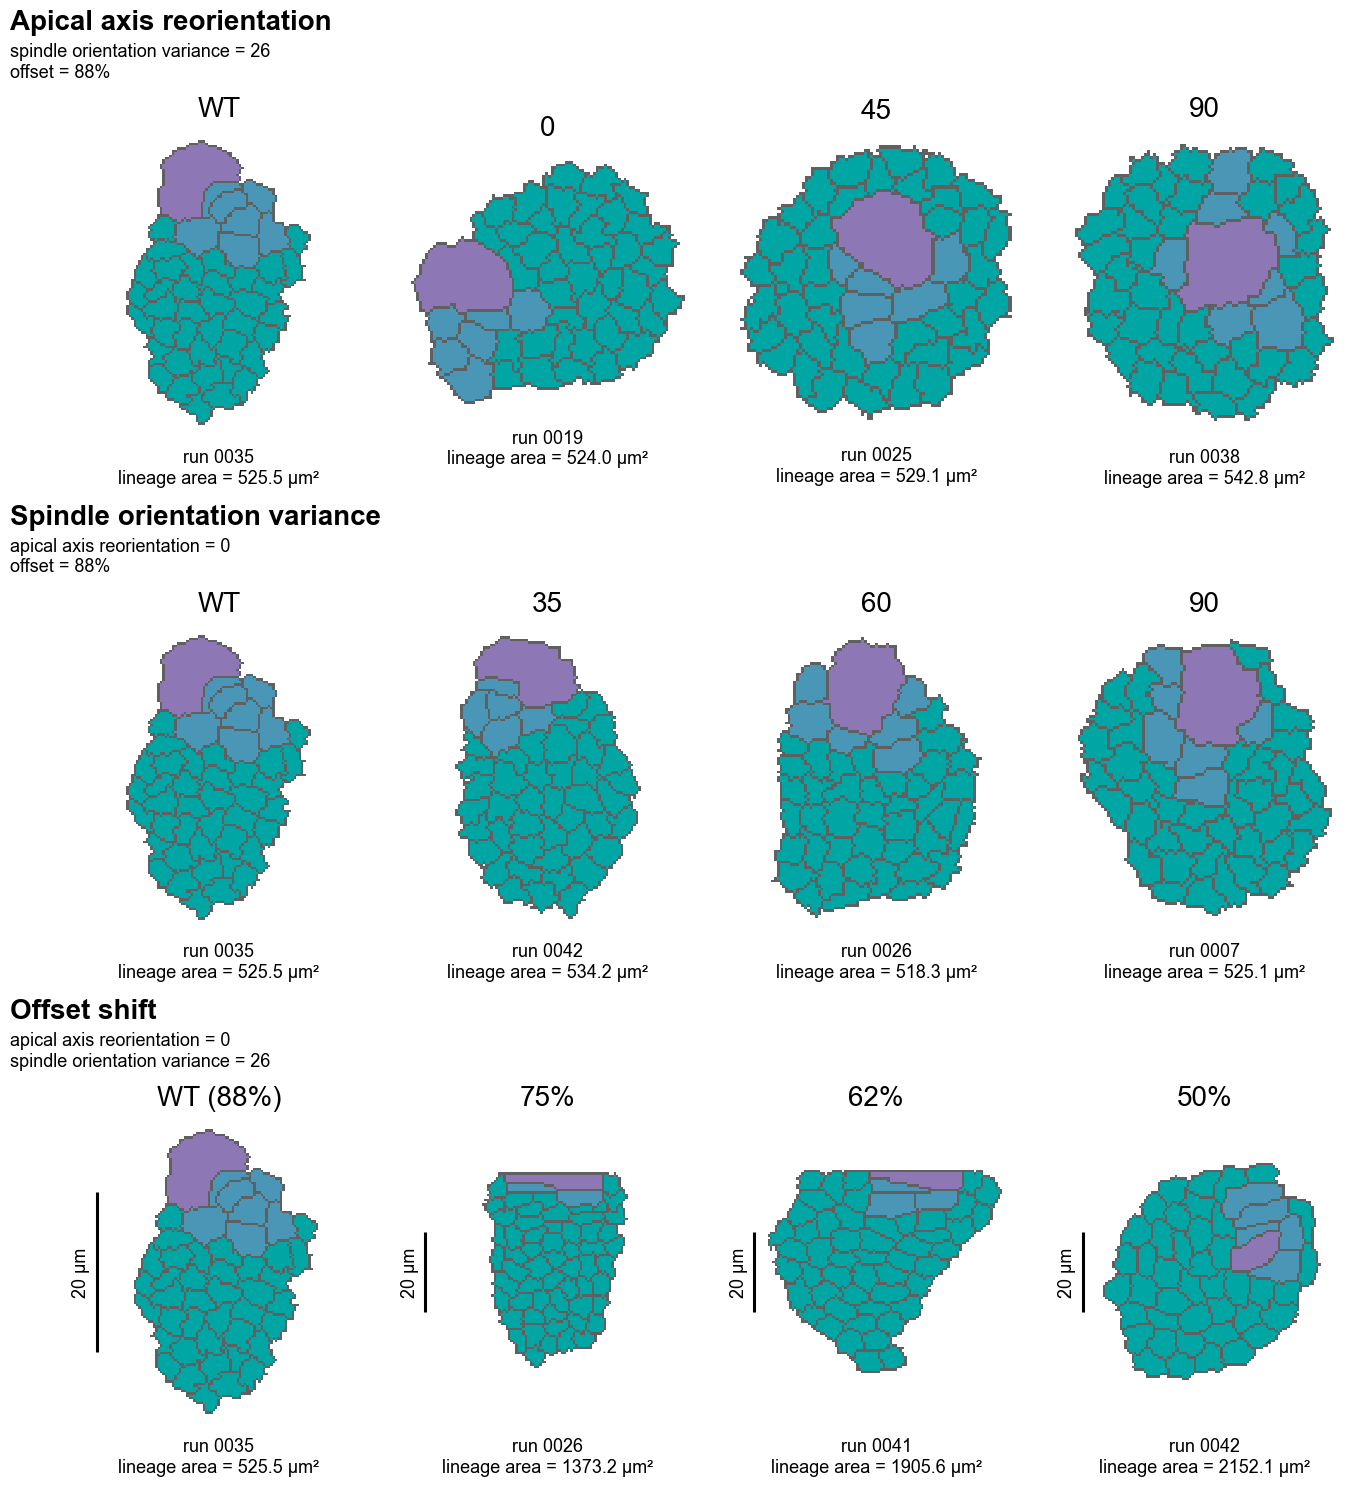

Saved: /Users/skjannetty/bagherilab/neurogen-plane-rotation-analysis/docs/tex_draft/figures/figure2_wt_mixing_panel.png
Saved: /Users/skjannetty/bagherilab/neurogen-plane-rotation-analysis/docs/tex_draft/figures/figure2_wt_mixing_panel.pdf


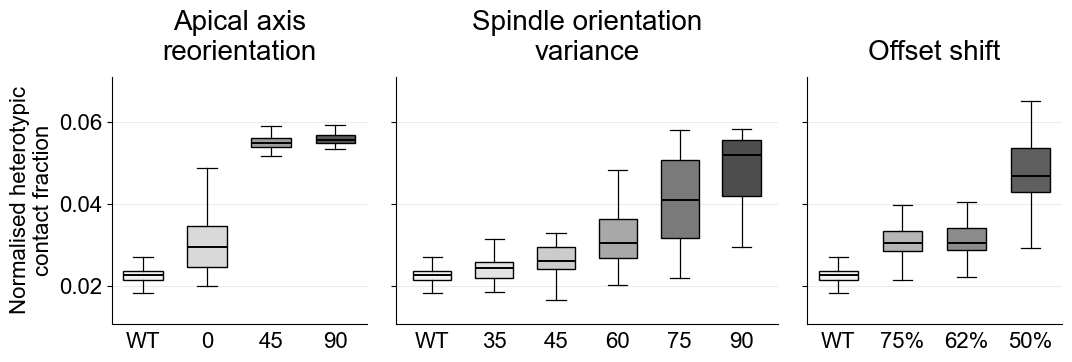

Saved: /Users/skjannetty/bagherilab/neurogen-plane-rotation-analysis/docs/tex_draft/figures/figure2_wt_exposure_panel.png
Saved: /Users/skjannetty/bagherilab/neurogen-plane-rotation-analysis/docs/tex_draft/figures/figure2_wt_exposure_panel.pdf


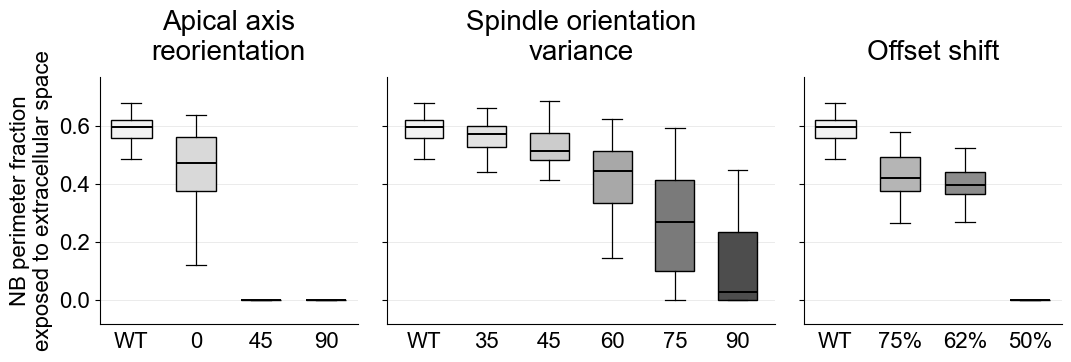

Saved: /Users/skjannetty/bagherilab/neurogen-plane-rotation-analysis/docs/tex_draft/figures/figure2_wt_composition_panel.png
Saved: /Users/skjannetty/bagherilab/neurogen-plane-rotation-analysis/docs/tex_draft/figures/figure2_wt_composition_panel.pdf


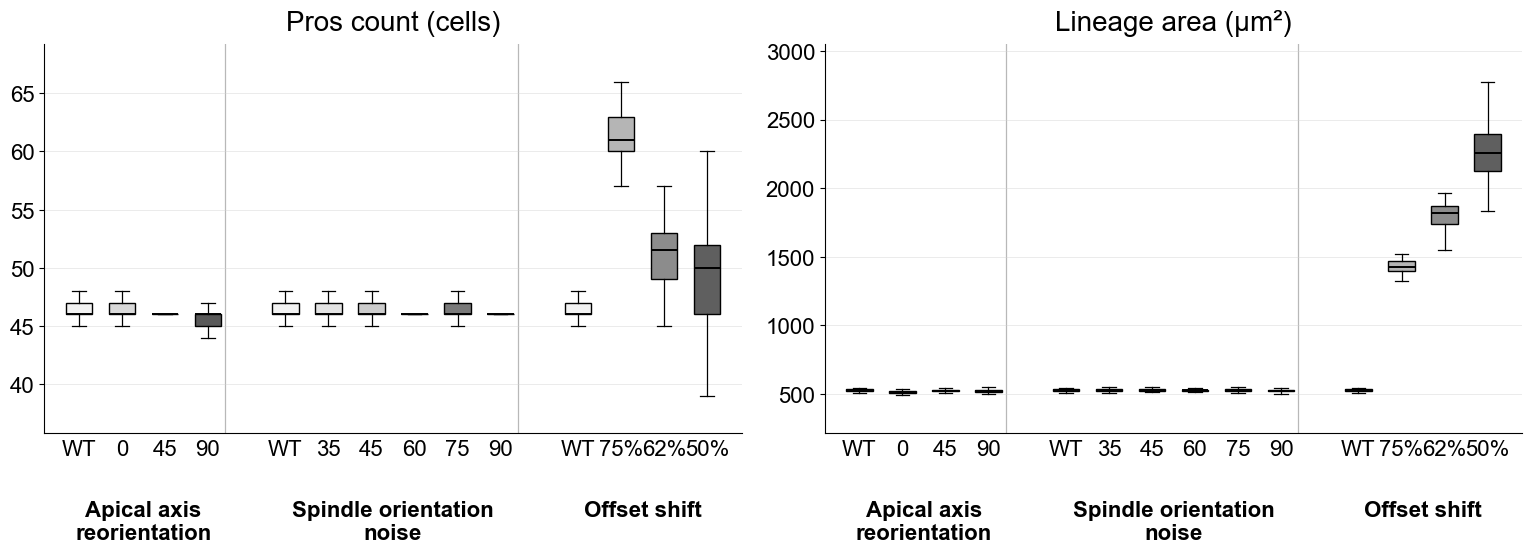

In [8]:
DECOUPLING_METRICS_CSV = REPO_ROOT / "data" / "sim" / "processed_decoupling" / "sim_metrics_last.csv"
DECOUPLING_RUN_INDEX_CSV = REPO_ROOT / "data" / "sim" / "processed_decoupling" / "sim_run_index.csv"

FIG2_SIM_ID = "vcv1_noreg"

decoupling_metrics_df = pd.read_csv(DECOUPLING_METRICS_CSV)
decoupling_run_index_df = pd.read_csv(DECOUPLING_RUN_INDEX_CSV)

FIG2_RELROT_CONDITIONS = [
    "wt_divMean0Stdev26",
    "wt_divMean0Stdev26_relrot",
    "wt_divMean45Stdev26_relrot",
    "wt_divMean90Stdev26_relrot",
]
FIG2_STDEV_CONDITIONS = [
    "wt_divMean0Stdev26",
    "wt_divMean0Stdev35",
    "wt_divMean0Stdev45",
    "wt_divMean0Stdev60",
    "wt_divMean0Stdev75",
    "wt_divMean0Stdev90",
]
FIG2_OFFSET_CONDITIONS = [
    "wt_divMean0Stdev26",
    "wt_divMean0Stdev26_yoffset75",
    "wt_divMean0Stdev26_yoffset62",
    "wt_divMean0Stdev26_yoffset50",
]
FIG2_GROUPS = [
    ("Apical axis reorientation", FIG2_RELROT_CONDITIONS),
    ("Spindle orientation variance", FIG2_STDEV_CONDITIONS),
    ("Offset shift", FIG2_OFFSET_CONDITIONS),
]
FIG2_LINEAGE_ROWS = [
    ("Apical axis reorientation", "spindle orientation variance = 26\noffset = 88%", FIG2_RELROT_CONDITIONS),
    ("Spindle orientation variance", "apical axis reorientation = 0\noffset = 88%", ["wt_divMean0Stdev26", "wt_divMean0Stdev35", "wt_divMean0Stdev60", "wt_divMean0Stdev90"]),
    ("Offset shift", "apical axis reorientation = 0\nspindle orientation variance = 26", FIG2_OFFSET_CONDITIONS),
]

FIG2_SHORT_LABELS = {
    "wt_divMean0Stdev26": "WT",
    "wt_divMean0Stdev26_relrot": "0",
    "wt_divMean45Stdev26_relrot": "45",
    "wt_divMean90Stdev26_relrot": "90",
    "wt_divMean0Stdev35": "35",
    "wt_divMean0Stdev45": "45",
    "wt_divMean0Stdev60": "60",
    "wt_divMean0Stdev75": "75",
    "wt_divMean0Stdev90": "90",
    "wt_divMean0Stdev26_yoffset75": "75%",
    "wt_divMean0Stdev26_yoffset62": "62%",
    "wt_divMean0Stdev26_yoffset50": "50%",
}
FIG2_LINEAGE_LABEL_OVERRIDES = {
    "wt_divMean0Stdev26__offset_row": "WT (88%)",
    "wt_divMean0Stdev26_yoffset75": "75%",
    "wt_divMean0Stdev26_yoffset62": "62%",
    "wt_divMean0Stdev26_yoffset50": "50%",
}
FIG2_LINEAGE_RUN_OVERRIDES = {"wt_divMean0Stdev26": 35}
FIG2_BOX_FILLS = {
    "wt_divMean0Stdev26": "#f2f2f2",
    "wt_divMean0Stdev26_relrot": "#d9d9d9",
    "wt_divMean45Stdev26_relrot": "#9e9e9e",
    "wt_divMean90Stdev26_relrot": "#595959",
    "wt_divMean0Stdev35": "#e3e3e3",
    "wt_divMean0Stdev45": "#cccccc",
    "wt_divMean0Stdev60": "#a8a8a8",
    "wt_divMean0Stdev75": "#7a7a7a",
    "wt_divMean0Stdev90": "#4d4d4d",
    "wt_divMean0Stdev26_yoffset75": "#b5b5b5",
    "wt_divMean0Stdev26_yoffset62": "#8c8c8c",
    "wt_divMean0Stdev26_yoffset50": "#5f5f5f",
}
FIG2_ALL_CONDITIONS = sorted({condition for _, conditions in FIG2_GROUPS for condition in conditions})
decoupling_run_index_vcv1 = decoupling_run_index_df.loc[
    (decoupling_run_index_df["sim_id"] == FIG2_SIM_ID)
    & (decoupling_run_index_df["condition"].isin(FIG2_ALL_CONDITIONS))
].copy()


FIG2_OFFSET_DISPLAY_SIZE = 200
FIG2_OFFSET_PERTURBED_DOWNSAMPLE_STEP = 2
FIG2_OFFSET_CROP_PAD = 4


@lru_cache(maxsize=None)
def decoupling_canvas_size(condition: str) -> int:
    row = decoupling_run_index_vcv1.loc[
        decoupling_run_index_vcv1["condition"] == condition
    ].iloc[0]
    sim_dir = (REPO_ROOT / row["cells_path"]).parent
    config_paths = [
        path
        for path in sim_dir.glob("*.json")
        if ".CELLS." not in path.name and ".LOCATIONS." not in path.name
    ]
    if len(config_paths) != 1:
        raise ValueError(f"Expected one sim config JSON in {sim_dir}, found {len(config_paths)}")
    config = json.loads(config_paths[0].read_text())
    size = config.get("size", {})
    length = int(size.get("length", 200))
    width = int(size.get("width", length))
    return max(length, width)


def downsample_to_canvas(
    geo_raw: np.ndarray,
    label_map: np.ndarray,
    target_size: int = FIG2_OFFSET_DISPLAY_SIZE,
) -> tuple[np.ndarray, np.ndarray, int]:
    source_size = int(geo_raw.shape[0])
    if geo_raw.shape[0] != geo_raw.shape[1]:
        raise ValueError(f"Expected square raw tensor, got {geo_raw.shape}")
    if label_map.shape != geo_raw.shape[:2]:
        raise ValueError("label_map shape must match geo_raw spatial dimensions")
    if source_size == target_size:
        return geo_raw, label_map, 1
    if source_size % target_size != 0:
        raise ValueError(
            f"Cannot downsample {source_size}x{source_size} canvas to {target_size}x{target_size} by integer stride"
        )
    step = source_size // target_size
    return geo_raw[::step, ::step, :], label_map[::step, ::step], step

def heterotypic_contact_fraction_raw(geo_raw: np.ndarray) -> dict[str, float]:
    nb = geo_raw[..., 0] > 0
    nonnb = (geo_raw[..., 1] > 0) | (geo_raw[..., 2] > 0)
    occ = nb | nonnb
    a_h = occ[:, :-1] & occ[:, 1:]
    a_v = occ[:-1, :] & occ[1:, :]
    heterotypic_h = a_h & (nb[:, :-1] != nb[:, 1:])
    heterotypic_v = a_v & (nb[:-1, :] != nb[1:, :])
    total_contacts = int(a_h.sum() + a_v.sum())
    het_contacts = int(heterotypic_h.sum() + heterotypic_v.sum())
    het_frac = float(het_contacts / total_contacts) if total_contacts > 0 else np.nan
    n_occupied = int(occ.sum())
    if n_occupied == 0:
        return {
            "het_frac": np.nan,
            "norm_het_frac": np.nan,
            "p_nb": np.nan,
            "p_nonnb": np.nan,
            "n_occupied": 0,
        }
    p_nb = float(nb[occ].mean())
    p_nonnb = float(nonnb[occ].mean())
    expected = 2.0 * p_nb * p_nonnb
    norm_het_frac = float(het_frac / expected) if expected > 0 else np.nan
    return {
        "het_frac": het_frac,
        "norm_het_frac": norm_het_frac,
        "p_nb": p_nb,
        "p_nonnb": p_nonnb,
        "n_occupied": n_occupied,
    }


def nb_exposure_metrics_raw(geo_raw: np.ndarray) -> dict[str, float]:
    nb = geo_raw[..., 0] > 0
    nonnb = (geo_raw[..., 1] > 0) | (geo_raw[..., 2] > 0)
    occ = nb | nonnb
    exposed_h = (nb[:, :-1] & ~occ[:, 1:]) | (~occ[:, :-1] & nb[:, 1:])
    exposed_v = (nb[:-1, :] & ~occ[1:, :]) | (~occ[:-1, :] & nb[1:, :])
    contact_h = (nb[:, :-1] & nonnb[:, 1:]) | (nonnb[:, :-1] & nb[:, 1:])
    contact_v = (nb[:-1, :] & nonnb[1:, :]) | (nonnb[:-1, :] & nb[1:, :])
    n_exposed = int(exposed_h.sum() + exposed_v.sum())
    n_contact = int(contact_h.sum() + contact_v.sum())
    n_perimeter = n_exposed + n_contact
    exposed_frac = float(n_exposed / n_perimeter) if n_perimeter > 0 else np.nan
    return {
        "exposed_frac": exposed_frac,
        "n_exposed": n_exposed,
        "n_contact": n_contact,
        "n_perimeter": n_perimeter,
    }


def load_decoupling_snapshot(condition: str, run_id: int) -> tuple[np.ndarray, np.ndarray, pd.Series]:
    row = decoupling_run_index_vcv1[
        (decoupling_run_index_vcv1["condition"] == condition)
        & (decoupling_run_index_vcv1["run_id"].astype(int) == int(run_id))
    ].iloc[0]
    cells_path = REPO_ROOT / row["cells_path"]
    locs_path = REPO_ROOT / row["locs_path"]
    canvas_size = decoupling_canvas_size(condition)
    if canvas_size == 200:
        geo_raw, label_map = load_raw_snapshot_full(cells_path, locs_path)
    else:
        cells_json = _load_json(cells_path)
        locs_json = _load_json(locs_path)
        geo_raw = build_raw_tensor(cells_json=cells_json, locs_json=locs_json, canvas_size=canvas_size)
        label_map = build_label_map(cells_json=cells_json, locs_json=locs_json, canvas_size=canvas_size)
    return geo_raw, label_map, row


def compute_decoupling_spatial_metrics(run_index_df: pd.DataFrame) -> pd.DataFrame:
    records = []
    for _, row in run_index_df.iterrows():
        condition = str(row["condition"])
        run_id = int(row["run_id"])
        geo_raw, _, _ = load_decoupling_snapshot(condition, run_id)
        record = {
            "condition": condition,
            "sim_id": str(row["sim_id"]),
            "run_id": run_id,
        }
        record.update(heterotypic_contact_fraction_raw(geo_raw))
        record.update(nb_exposure_metrics_raw(geo_raw))
        records.append(record)
    return pd.DataFrame(records)


decoupling_spatial_df = compute_decoupling_spatial_metrics(decoupling_run_index_vcv1)
decoupling_vcv1 = decoupling_metrics_df.loc[
    (decoupling_metrics_df["sim_id"] == FIG2_SIM_ID)
    & (decoupling_metrics_df["condition"].isin(FIG2_ALL_CONDITIONS))
].merge(
    decoupling_spatial_df,
    on=["condition", "sim_id", "run_id"],
    how="left",
    validate="one_to_one",
).sort_values(["condition", "run_id"])


def pick_condition_representative_rows(
    df: pd.DataFrame,
    conditions: list[str],
    metric: str = "lin_area_vox",
    quantile: float = 0.5,
    target_mode: str = "quantile",
) -> pd.DataFrame:
    rows = []
    for condition in conditions:
        subset = df.loc[df["condition"] == condition].copy()
        if condition in FIG2_LINEAGE_RUN_OVERRIDES:
            run_id = int(FIG2_LINEAGE_RUN_OVERRIDES[condition])
            row = subset.loc[subset["run_id"].astype(int) == run_id].iloc[0]
            payload = row.to_dict()
            target = float(subset[metric].mean()) if target_mode == "mean" else float(subset[metric].quantile(quantile))
            payload["target_value"] = target
            rows.append(payload)
            continue
        if target_mode == "mean":
            target = float(subset[metric].mean())
        elif target_mode == "quantile":
            target = float(subset[metric].quantile(quantile))
        else:
            raise ValueError(f"Unknown target_mode: {target_mode}")
        subset["abs_delta"] = (subset[metric] - target).abs()
        row = subset.sort_values(["abs_delta", metric, "run_id"], kind="stable").iloc[0]
        payload = row.drop(labels=["abs_delta"]).to_dict()
        payload["target_value"] = target
        rows.append(payload)
    return pd.DataFrame(rows)


def pick_condition_representative_rows_joint(
    df: pd.DataFrame,
    conditions: list[str],
    metrics: list[str],
    quantile: float = 0.5,
    target_mode: str = "quantile",
) -> pd.DataFrame:
    rows = []
    for condition in conditions:
        subset = df.loc[df["condition"] == condition].copy()
        if condition in FIG2_LINEAGE_RUN_OVERRIDES:
            run_id = int(FIG2_LINEAGE_RUN_OVERRIDES[condition])
            row = subset.loc[subset["run_id"].astype(int) == run_id].iloc[0]
            drop_cols = [c for c in subset.columns if c.endswith("_target_delta") or c == "joint_score"]
            payload = row.drop(labels=[c for c in drop_cols if c in row.index]).to_dict()
            for metric in metrics:
                payload[f"target_{metric}"] = float(subset[metric].mean()) if target_mode == "mean" else float(subset[metric].quantile(quantile))
            rows.append(payload)
            continue
        for metric in metrics:
            if target_mode == "mean":
                target = float(subset[metric].mean())
            elif target_mode == "quantile":
                target = float(subset[metric].quantile(quantile))
            else:
                raise ValueError(f"Unknown target_mode: {target_mode}")
            std = float(subset[metric].std(ddof=0))
            if not np.isfinite(std) or std == 0.0:
                std = 1.0
            subset[f"{metric}_target_delta"] = (subset[metric] - target).abs() / std
        subset["joint_score"] = np.sqrt(np.sum([subset[f"{metric}_target_delta"] ** 2 for metric in metrics], axis=0))
        row = subset.sort_values(["joint_score", "run_id"], kind="stable").iloc[0]
        drop_cols = [f"{metric}_target_delta" for metric in metrics] + ["joint_score"]
        payload = row.drop(labels=drop_cols).to_dict()
        for metric in metrics:
            payload[f"target_{metric}"] = float(subset[metric].mean()) if target_mode == "mean" else float(subset[metric].quantile(quantile))
        rows.append(payload)
    return pd.DataFrame(rows)


def fig2_metric_values(df: pd.DataFrame, condition: str, metric_key: str, is_area: bool = False) -> np.ndarray:
    values = df.loc[df["condition"] == condition, metric_key].astype(float).to_numpy()
    if is_area:
        values = values * AREA_SCALE
    return values


def style_publication_axis(ax: plt.Axes) -> None:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", color="#d0d0d0", linewidth=0.6, alpha=0.5)
    ax.tick_params(axis="x", length=0, labelsize=FONT_SIZE_LABEL, pad=4)
    ax.tick_params(axis="y", labelsize=FONT_SIZE_LABEL)


def boxplot_metric(ax: plt.Axes, df: pd.DataFrame, conditions: list[str], metric_key: str, is_area: bool = False) -> None:
    values = [fig2_metric_values(df, condition, metric_key, is_area=is_area) for condition in conditions]
    positions = np.arange(1, len(conditions) + 1, dtype=float)
    bp = ax.boxplot(
        values,
        positions=positions,
        widths=0.62,
        patch_artist=True,
        showfliers=False,
        medianprops={"color": "black", "linewidth": 1.4},
        boxprops={"facecolor": "white", "edgecolor": "black", "linewidth": 1.0},
        whiskerprops={"color": "black", "linewidth": 0.9},
        capprops={"color": "black", "linewidth": 0.9},
        manage_ticks=False,
        zorder=3,
    )
    for patch, condition in zip(bp["boxes"], conditions):
        patch.set_facecolor(FIG2_BOX_FILLS[condition])
    ax.set_xticks(positions, [FIG2_SHORT_LABELS[condition] for condition in conditions])
    style_publication_axis(ax)


def grouped_metric_limits(group_defs: list[tuple[str, list[str]]], metric_key: str, is_area: bool = False) -> tuple[float, float]:
    all_values = []
    for _, conditions in group_defs:
        for condition in conditions:
            values = fig2_metric_values(decoupling_vcv1, condition, metric_key, is_area=is_area)
            all_values.append(values)
    flat = np.concatenate(all_values)
    lo = float(flat.min())
    hi = float(flat.max())
    span = hi - lo
    pad = 0.12 * span if span > 0 else 0.2 * max(1.0, abs(hi))
    return lo - pad, hi + pad


def add_vertical_scale_bar(ax: plt.Axes, pixels_per_um: float,
                            length_um: float = 20, color: str = "black",
                            lw: float = 2.2) -> None:
    bar_px = length_um * pixels_per_um
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    x_margin = (xlim[1] - xlim[0]) * 0.05
    y_mid = (ylim[0] + ylim[1]) / 2
    y0, y1 = y_mid - bar_px / 2, y_mid + bar_px / 2
    x_bar = xlim[0] - x_margin * 0.3
    ax.plot([x_bar, x_bar], [y0, y1], color=color, linewidth=lw,
            solid_capstyle="butt", clip_on=False)
    ax.text(x_bar - x_margin * 1.2, y_mid, f"{length_um:g} µm",
            ha="center", va="center", color=color,
            fontsize=FONT_SIZE_SMALL, rotation=90)


def make_figure2_lineages_panel() -> tuple[plt.Figure, list[list[plt.Axes]]]:
    fig = plt.figure(figsize=(13.8, 14.0))
    outer = fig.add_gridspec(len(FIG2_LINEAGE_ROWS), 1, hspace=0.58)
    row_axes: list[list[plt.Axes]] = []

    for row_idx, (row_title, row_subtitle, conditions) in enumerate(FIG2_LINEAGE_ROWS):
        if row_title == "Offset shift":
            reps = pick_condition_representative_rows_joint(decoupling_vcv1, conditions, metrics=["norm_het_frac", "exposed_frac"], target_mode="mean")
        else:
            reps = pick_condition_representative_rows(decoupling_vcv1, conditions, metric="norm_het_frac", target_mode="mean")
        inner = outer[row_idx].subgridspec(1, len(conditions), wspace=0.07)
        axes = []

        # Pre-compute uniform crop dimensions for offset-shift row
        if row_title == "Offset shift":
            _offset_crops_geo: list[np.ndarray] = []
            _offset_crops_lab: list[np.ndarray] = []
            _offset_ppum: list[float] = []
            for _, _orow in reps.iterrows():
                _cond = _orow["condition"]
                _geo_r, _lm_r, _ = load_decoupling_snapshot(_cond, int(_orow["run_id"]))
                if _cond == "wt_divMean0Stdev26":
                    _gc = crop_to_content(_geo_r, pad=6)
                    _lc = crop_to_content(_lm_r, pad=6)
                    _ppum = 1.0 / DS_UM_PER_VOX
                else:
                    _ds = FIG2_OFFSET_PERTURBED_DOWNSAMPLE_STEP
                    _gd = _geo_r[::_ds, ::_ds, :]
                    _ld = _lm_r[::_ds, ::_ds]
                    _gc = crop_to_content(_gd, pad=FIG2_OFFSET_CROP_PAD)
                    _lc = crop_to_content(_ld, pad=FIG2_OFFSET_CROP_PAD)
                    _ppum = (1.0 / DS_UM_PER_VOX) / _ds
                _offset_crops_geo.append(_gc)
                _offset_crops_lab.append(_lc)
                _offset_ppum.append(_ppum)
            _max_h = max(c.shape[0] for c in _offset_crops_geo)
            _max_w = max(c.shape[1] for c in _offset_crops_geo)

        for col_idx, (_, row) in enumerate(reps.iterrows()):
            ax = fig.add_subplot(inner[0, col_idx])
            condition = row["condition"]
            run_id = int(row["run_id"])
            if row_title == "Offset shift":
                geo_crop = _offset_crops_geo[col_idx]
                label_crop = _offset_crops_lab[col_idx]
                pixels_per_um = _offset_ppum[col_idx]
                # Pad to uniform size so all images match in pixel dimensions
                h, w = geo_crop.shape[:2]
                pt = (_max_h - h) // 2; pb = _max_h - h - pt
                pl = (_max_w - w) // 2; pr = _max_w - w - pl
                geo_crop = np.pad(geo_crop, ((pt, pb), (pl, pr), (0, 0)), constant_values=0)
                label_crop = np.pad(label_crop, ((pt, pb), (pl, pr)), constant_values=0)
                render_raw(geo_crop, ax=ax, label_map=label_crop, title="")
                add_vertical_scale_bar(ax, pixels_per_um=pixels_per_um)
            else:
                geo_raw, label_map, _ = load_decoupling_snapshot(condition, run_id)
                geo_crop = crop_to_content(geo_raw, pad=6)
                label_crop = crop_to_content(label_map, pad=6)
                render_raw(geo_crop, ax=ax, label_map=label_crop, title="")
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
            display_label = FIG2_SHORT_LABELS[condition]
            if row_title == "Offset shift" and condition == "wt_divMean0Stdev26":
                display_label = FIG2_LINEAGE_LABEL_OVERRIDES["wt_divMean0Stdev26__offset_row"]
            else:
                display_label = FIG2_LINEAGE_LABEL_OVERRIDES.get(condition, display_label)
            ax.set_title(display_label, pad=7, fontsize=FONT_SIZE_TITLE)
            ax.set_xlabel(
                f"run {run_id:04d}\nlineage area = {row['lin_area_vox'] * AREA_SCALE:.1f} µm²",
                fontsize=FONT_SIZE_SMALL,
                labelpad=2,
            )
            ax.xaxis.set_label_coords(0.5, -0.028)
            axes.append(ax)
        row_axes.append(axes)

    fig.subplots_adjust(left=0.055, right=0.992, top=0.985, bottom=0.055)
    for (row_title, row_subtitle, _), axes in zip(FIG2_LINEAGE_ROWS, row_axes):
        bbox = axes[0].get_position()
        fig.text(
            0.015,
            bbox.y1 + 0.065,
            row_title,
            fontsize=FONT_SIZE_TITLE,
            fontweight="bold",
            ha="left",
            va="bottom",
        )
        fig.text(
            0.015,
            bbox.y1 + 0.060,
            row_subtitle,
            fontsize=FONT_SIZE_SMALL,
            ha="left",
            va="top",
        )
    return fig, row_axes


def make_grouped_metric_panel(metric_key: str, ylabel: str, is_area: bool = False) -> tuple[plt.Figure, list[plt.Axes]]:
    fig, axes = plt.subplots(
        1,
        len(FIG2_GROUPS),
        figsize=(11.0, 3.9),
        sharey=True,
        gridspec_kw={"width_ratios": [len(conditions) for _, conditions in FIG2_GROUPS]},
    )
    title_map = {
        "Apical axis reorientation": "Apical axis\nreorientation",
        "Spindle orientation variance": "Spindle orientation\nvariance",
        "Offset shift": "Offset shift",
    }
    y0, y1 = grouped_metric_limits(FIG2_GROUPS, metric_key, is_area=is_area)
    for ax, (group_title, conditions) in zip(axes, FIG2_GROUPS):
        boxplot_metric(ax, decoupling_vcv1, conditions, metric_key, is_area=is_area)
        ax.tick_params(axis="x", labelsize=FONT_SIZE_LABEL, pad=6)
        ax.tick_params(axis="y", labelsize=FONT_SIZE_LABEL)
        ax.set_title(title_map.get(group_title, group_title), fontsize=FONT_SIZE_TITLE, pad=12)
        ax.set_ylim(y0, y1)
    axes[0].set_ylabel(ylabel, fontsize=FONT_SIZE_LABEL)
    fig.tight_layout()
    return fig, list(axes)


def flattened_group_positions(group_defs: list[tuple[str, list[str]]]) -> tuple[list[str], list[float], list[tuple[str, float, float]]]:
    conditions_flat: list[str] = []
    positions: list[float] = []
    spans: list[tuple[str, float, float]] = []
    x = 1.0
    for group_title, conditions in group_defs:
        start = x
        for condition in conditions:
            conditions_flat.append(condition)
            positions.append(x)
            x += 1.0
        spans.append((group_title, start, x - 1.0))
        x += 0.8
    return conditions_flat, positions, spans


def make_figure2_composition_panel() -> tuple[plt.Figure, list[plt.Axes]]:
    fig, axes = plt.subplots(1, 2, figsize=(15.6, 5.9))
    conditions_flat, positions, spans = flattened_group_positions(FIG2_GROUPS)
    metric_specs = [
        ("n_pros", "Pros count (cells)", False),
        ("lin_area_vox", "Lineage area (µm²)", True),
    ]

    for ax, (metric_key, title, is_area) in zip(axes, metric_specs):
        values = [fig2_metric_values(decoupling_vcv1, condition, metric_key, is_area=is_area) for condition in conditions_flat]
        bp = ax.boxplot(
            values,
            positions=positions,
            widths=0.62,
            patch_artist=True,
            showfliers=False,
            medianprops={"color": "black", "linewidth": 1.4},
            boxprops={"facecolor": "white", "edgecolor": "black", "linewidth": 1.0},
            whiskerprops={"color": "black", "linewidth": 0.9},
            capprops={"color": "black", "linewidth": 0.9},
            manage_ticks=False,
            zorder=3,
        )
        for patch, condition in zip(bp["boxes"], conditions_flat):
            patch.set_facecolor(FIG2_BOX_FILLS[condition])
        ax.set_xticks(positions, [FIG2_SHORT_LABELS[condition] for condition in conditions_flat])
        ax.tick_params(axis="x", labelsize=FONT_SIZE_LABEL, pad=3)
        ax.set_title(title, fontsize=FONT_SIZE_TITLE, pad=10)
        for _, start, end in spans[:-1]:
            ax.axvline(end + 0.4, color="#b8b8b8", linewidth=0.9, zorder=1)
        for group_title, start, end in spans:
            ax.text(
                0.5 * (start + end),
                -0.17,
                {"Apical axis reorientation": "Apical axis\nreorientation", "Spindle orientation variance": "Spindle orientation\nnoise", "Offset shift": "Offset shift"}.get(group_title, group_title),
                transform=ax.get_xaxis_transform(),
                ha="center",
                va="top",
                fontsize=FONT_SIZE_LABEL,
                fontweight="bold",
            )
        style_publication_axis(ax)
        lo, hi = grouped_metric_limits(FIG2_GROUPS, metric_key, is_area=is_area)
        ax.set_ylim(lo, hi)
        ax.set_xlim(min(positions) - 0.8, max(positions) + 0.8)
    fig.tight_layout()
    fig.subplots_adjust(bottom=0.24)
    return fig, list(axes)


figure2_examples_fig, figure2_examples_axes = make_figure2_lineages_panel()
figure2_examples_png = FIG_DIR / "figure2_wt_geometry_examples_panel.png"
figure2_examples_pdf = FIG_DIR / "figure2_wt_geometry_examples_panel.pdf"
figure2_examples_fig.savefig(figure2_examples_png, bbox_inches="tight", facecolor="white")
figure2_examples_fig.savefig(figure2_examples_pdf, bbox_inches="tight", facecolor="white")
print(f"Saved: {figure2_examples_png}")
print(f"Saved: {figure2_examples_pdf}")
plt.show()

figure2_mix_fig, figure2_mix_axes = make_grouped_metric_panel(
    metric_key="norm_het_frac",
    ylabel="Normalised heterotypic\ncontact fraction",
    is_area=False,
)
figure2_mix_png = FIG_DIR / "figure2_wt_mixing_panel.png"
figure2_mix_pdf = FIG_DIR / "figure2_wt_mixing_panel.pdf"
figure2_mix_fig.savefig(figure2_mix_png, bbox_inches="tight", facecolor="white")
figure2_mix_fig.savefig(figure2_mix_pdf, bbox_inches="tight", facecolor="white")
print(f"Saved: {figure2_mix_png}")
print(f"Saved: {figure2_mix_pdf}")
plt.show()

figure2_exposure_fig, figure2_exposure_axes = make_grouped_metric_panel(
    metric_key="exposed_frac",
    ylabel="NB perimeter fraction\nexposed to extracellular space",
    is_area=False,
)
figure2_exposure_png = FIG_DIR / "figure2_wt_exposure_panel.png"
figure2_exposure_pdf = FIG_DIR / "figure2_wt_exposure_panel.pdf"
figure2_exposure_fig.savefig(figure2_exposure_png, bbox_inches="tight", facecolor="white")
figure2_exposure_fig.savefig(figure2_exposure_pdf, bbox_inches="tight", facecolor="white")
print(f"Saved: {figure2_exposure_png}")
print(f"Saved: {figure2_exposure_pdf}")
plt.show()

figure2_comp_fig, figure2_comp_axes = make_figure2_composition_panel()
figure2_comp_png = FIG_DIR / "figure2_wt_composition_panel.png"
figure2_comp_pdf = FIG_DIR / "figure2_wt_composition_panel.pdf"
figure2_comp_fig.savefig(figure2_comp_png, bbox_inches="tight", facecolor="white")
figure2_comp_fig.savefig(figure2_comp_pdf, bbox_inches="tight", facecolor="white")
print(f"Saved: {figure2_comp_png}")
print(f"Saved: {figure2_comp_pdf}")
plt.show()
